In [164]:
# ACC102 Track 2 Mini Assignment
# Global Inflation and Unemployment Analysis

# 1. Import Required Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

# Display all columns for easier checking
pd.set_option("display.max_columns", None)

In [165]:
# 2. Problem Definition

print("Research Question:")
print("Does higher inflation relate to lower unemployment in major economies from 2015 to 2024?")

Research Question:
Does higher inflation relate to lower unemployment in major economies from 2015 to 2024?


In [166]:
# 3. Screen the data of the designated year

# World Bank CSV files contain metadata in the first 4 rows, therefore, skiprows=4 is required
inflation_raw = pd.read_csv(data_path / "inflation.csv", skiprows=4)
unemployment_raw = pd.read_csv(data_path / "unemployment.csv", skiprows=4)

# Filter data for 2015 to 2024(The original dataset had years as column headers, making it difficult to filter by year, so I transformed the data from wide format to long format)

inflation_raw = inflation_raw.melt(id_vars=["Country Name"], var_name="Year", value_name="Inflation Rate")
unemployment_raw = unemployment_raw.melt(id_vars=["Country Name"], var_name="Year", value_name="Unemployment Rate")

inflation_raw['Year'] = pd.to_numeric(inflation_raw['Year'], errors='coerce')
unemployment_raw['Year'] = pd.to_numeric(unemployment_raw['Year'], errors='coerce')

inflation_raw = inflation_raw[inflation_raw['Year'].between(2015, 2024)]
unemployment_raw = unemployment_raw[unemployment_raw['Year'].between(2015, 2024)]

# Display 
print("Inflation Data Preview (2015-2024)")
display(inflation_raw)

print("Unemployment Data Preview (2015-2024)")
display(unemployment_raw)

Inflation Data Preview (2015-2024)


,Country Name,Year,Inflation Rate
15428,Aruba,2015.0,0.474764
15429,Africa Eastern and Southern,2015.0,5.098562
15430,Afghanistan,2015.0,-0.661709
15431,Africa Western and Central,2015.0,2.130817
15432,Angola,2015.0,9.355972
...,...,...,...
18083,Kosovo,2024.0,1.61945
18084,"Yemen, Rep.",2024.0,NaN
18085,South Africa,2024.0,4.361152
18086,Zambia,2024.0,14.985626


Unemployment Data Preview (2015-2024)


,Country Name,Year,Unemployment Rate
15428,Aruba,2015.0,NaN
15429,Africa Eastern and Southern,2015.0,6.930941
15430,Afghanistan,2015.0,9.032
15431,Africa Western and Central,2015.0,4.170143
15432,Angola,2015.0,16.472
...,...,...,...
18083,Kosovo,2024.0,NaN
18084,"Yemen, Rep.",2024.0,16.97
18085,South Africa,2024.0,32.279
18086,Zambia,2024.0,5.898


In [167]:
# 4. Data Cleaning

# Filter Data for Selected Countries 
selected_countries = ["China","United States","United Kingdom","Germany","Japan"]
inflation_clean = inflation_raw[inflation_raw['Country Name'].isin(selected_countries)]
unemployment_clean = unemployment_raw[unemployment_raw['Country Name'].isin(selected_countries)]

# Handle Missing Values
inflation_clean = inflation_clean.dropna(subset=['Inflation Rate'])
unemployment_clean = unemployment_clean.dropna(subset=['Unemployment Rate'])

# Concatenating dataframes
merged_data = pd.concat([inflation_clean.set_index(['Country Name', 'Year']), 
                         unemployment_clean.set_index(['Country Name', 'Year'])], axis=1)

# Display merged data
display(merged_data)

,,Inflation Rate,Unemployment Rate
Country Name,Year,,
China,2015.0,1.437024,4.65
Germany,2015.0,0.514426,4.612
United Kingdom,2015.0,0.368047,5.552
Japan,2015.0,0.79528,3.385
United States,2015.0,0.118627,5.28
China,2016.0,2.000002,4.56
Germany,2016.0,0.491747,4.104
United Kingdom,2016.0,1.008417,4.909
Japan,2016.0,-0.127259,3.132


In [171]:
# 5. Manually Calculate Pearson Correlation Coefficient

merged_df = merged_df.dropna(subset=["Inflation_Rate", "Unemployment_Rate"])

# Extract the Inflation Rate and Unemployment Rate data
inflation = merged_df["Inflation_Rate"]
unemployment = merged_df["Unemployment_Rate"]

# Calculate the mean of each variable
mean_inflation = np.mean(inflation)
mean_unemployment = np.mean(unemployment)

# Calculate the difference from the mean for each data point
diff_inflation = inflation - mean_inflation
diff_unemployment = unemployment - mean_unemployment

# Calculate the Pearson correlation coefficient
correlation_coefficient = merged_df["Inflation_Rate"].corr(merged_df["Unemployment_Rate"])

# Output the result
print(f"Pearson correlation coefficient: {correlation_coefficient:.2f}")

Pearson correlation coefficient: -0.10


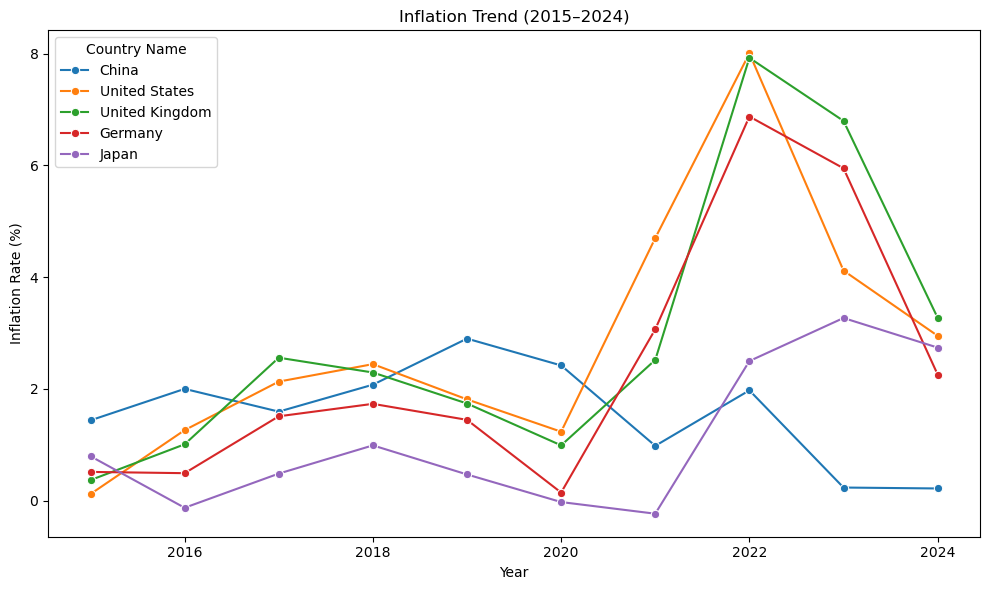

In [172]:
# 6. Visualization 
# Inflation Trend by Country

plt.figure(figsize=(10, 6))

sns.lineplot(data=merged_df,
                x="Year",
                y="Inflation_Rate",
              hue="Country Name",
           marker="o")

plt.title("Inflation Trend (2015–2024)")
plt.xlabel("Year")
plt.ylabel("Inflation Rate (%)")

plt.tight_layout()

plt.savefig(figure_path / "inflation_trend.png",dpi=300)

plt.show()

In [173]:
# 7. Business Interpretation

print("Key Insight:")

if correlation_coefficient < 0:
    print("The result shows a negative relationship between inflation and unemployment, which partially supports the Phillips Curve theory.")
else:
    print("The result does not show a strong negative relationship, suggesting that inflation and unemployment may be influenced by multiple economic factors.")

Key Insight:
The result shows a negative relationship between inflation and unemployment, which partially supports the Phillips Curve theory.
